# Student Academic Performance Prediction Using Decision Tree

**Gan Koh Jun (26WMR12824)** &nbsp;&middot;&nbsp; BMCS2203 Artificial Intelligence, Session 202605
&nbsp;&middot;&nbsp; Title 1: Machine Learning (Supervised) &nbsp;&middot;&nbsp; Assigned model: **Decision Tree**

Dataset: `StudentPerformanceFactors.csv` &mdash; 6,607 student records, 20 original columns.
The target `Performance` is derived from `Exam_Score` and has three classes: **Low**, **Medium**, **High**.

---

### What this notebook contains

| Section | What it does | Assignment requirement |
|---|---|---|
| **1** | Load the file, validate it, cap out-of-range scores, derive the Low / Medium / High target | (c) search for the dataset |
| **1a** | Build two engineered features: `Support_Index` and `Study_Consistency` | (d) feature engineering |
| **2** | Remove the leakage columns, then split 80% train / 20% test with stratification | (d) data representation |
| **3** | Impute missing values and one-hot encode categorical features, assemble the decision tree pipeline | (d) missing values + normalization, (e) |
| **4** | Tune the model with `GridSearchCV` over criterion, depth, split/leaf sizes and a data-informed cost-complexity pruning sweep | (e) provide a solution using Decision Tree |
| **4.1** | Pruning curve: how training and cross-validation accuracy change as the tree is pruned | Extra work beyond the basic requirements |
| **5** | Accuracy, precision, recall, F1, the confusion matrix, and a majority-class baseline | (f) evaluation metrics |
| **5.1** | Actual student counts versus predicted counts, and the class balance of the dataset | Tutor's requirement, 26 August |
| **6** | Feature importance: which factors the tree actually splits on | Documentation: methodology / algorithm description |
| **7** | `predict_student()`: validates one new student record and returns a class with probabilities | Prototype: programming and validation |
| **8** | Interpretation of the numbers produced in Section 5, including the measured effect of feature engineering | Documentation: results and discussion |
| **9** | Head-to-head comparison with KNN and Logistic Regression on the identical test set | (f) compare methods |
| **10** | Comparison with published Decision Tree / KNN studies | (b) background study |
| **11** | Achievements, limitations, and future work | Documentation: conclusion |

This notebook uses the same dataset, the same target definition, and the same `random_state=42`
stratified 80/20 split as `KNN.ipynb` and `LogisticRegression.ipynb`, so all three models are
trained and tested on identical data and the head-to-head comparison in Section 9 is valid. The
group's full three-way results table also lives in `README.md`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

## 1. Dataset preparation

The dataset is loaded through a validated loader that checks the file, the required columns, and the target values before any modelling begins. The dataset is then inspected for its size, missing values, and duplicated records, and `Exam_Score` is converted into the target classes below.

| Exam score | Performance class |
|---|---|
| 64 or below | Low |
| 65 to 69 | Medium |
| 70 or above | High |

Dataset source: Student Performance Factors, Kaggle (https://www.kaggle.com/datasets/lainguyn123/student-performance-factors).

Loaded 'StudentPerformanceFactors.csv' successfully. All 20 required columns are present.
Data quality issue: 1 row(s) have Exam_Score outside 0-100.
      Exam_Score
1525         101
Out-of-range value(s) capped to [0, 100].
Data validation passed: all 6607 rows have a Exam_Score between 0 and 100 with no missing values.

Dataset shape: (6607, 20)
Duplicated rows: 0
Exam_Score range: 55 to 100

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Performance class distribution:
Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64


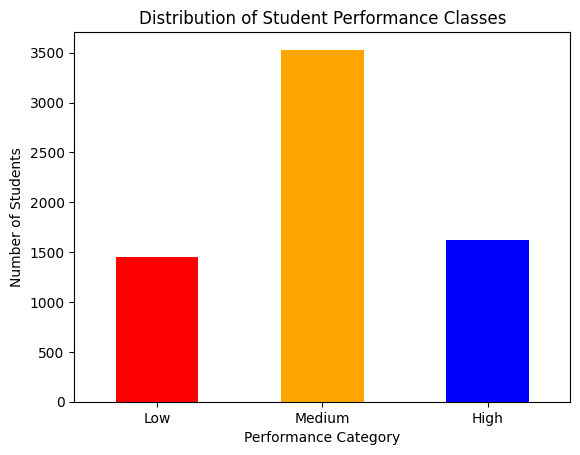

In [2]:
DATA_FILE = "StudentPerformanceFactors.csv"
TARGET_COLUMN = "Exam_Score"

REQUIRED_COLUMNS = [
    "Hours_Studied", "Attendance", "Parental_Involvement", "Access_to_Resources",
    "Extracurricular_Activities", "Sleep_Hours", "Previous_Scores", "Motivation_Level",
    "Internet_Access", "Tutoring_Sessions", "Family_Income", "Teacher_Quality",
    "School_Type", "Peer_Influence", "Physical_Activity", "Learning_Disabilities",
    "Parental_Education_Level", "Distance_from_Home", "Gender", "Exam_Score"
]


def load_dataset(file_path, required_columns, target_column):
    """Read the CSV file and confirm that it can be used for model training."""
    try:
        data = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"'{file_path}' was not found. "
            "Place the CSV file in the same folder as this notebook."
        )
    except pd.errors.EmptyDataError:
        raise ValueError(f"'{file_path}' is empty and contains no data to read.")
    except pd.errors.ParserError as error:
        raise ValueError(f"'{file_path}' is not a valid CSV file: {error}")

    if data.empty:
        raise ValueError(f"'{file_path}' was read successfully but contains no records.")

    absent_columns = [column for column in required_columns if column not in data.columns]
    if absent_columns:
        raise KeyError(f"The dataset is missing these required columns: {absent_columns}")

    if not pd.api.types.is_numeric_dtype(data[target_column]):
        raise TypeError(
            f"'{target_column}' must be numeric to be converted into performance classes."
        )

    if data[target_column].isnull().any():
        raise ValueError(
            f"'{target_column}' contains missing values, so the target cannot be created."
        )

    return data


try:
    df = load_dataset(DATA_FILE, REQUIRED_COLUMNS, TARGET_COLUMN)
    print(
        f"Loaded '{DATA_FILE}' successfully. "
        f"All {len(REQUIRED_COLUMNS)} required columns are present."
    )
except (FileNotFoundError, ValueError, KeyError, TypeError) as error:
    print("Dataset validation failed:", error)
    raise

# Business rules on the target column.
# Exam_Score is a 0-100 percentage, so any value outside that range is a data-entry
# error. It is capped rather than dropped so that no student record is discarded.
out_of_range = ((df[TARGET_COLUMN] < 0) | (df[TARGET_COLUMN] > 100)).sum()
if out_of_range > 0:
    print(f"Data quality issue: {out_of_range} row(s) have {TARGET_COLUMN} outside 0-100.")
    print(df.loc[(df[TARGET_COLUMN] < 0) | (df[TARGET_COLUMN] > 100), [TARGET_COLUMN]])
    df[TARGET_COLUMN] = df[TARGET_COLUMN].clip(lower=0, upper=100)
    print("Out-of-range value(s) capped to [0, 100].")

# These assertions turn the checks above into hard guarantees. If a future version of
# the dataset still breaks one of these rules, the notebook stops here with a clear
# message instead of silently training on invalid data.
assert df.shape[0] > 0, "Dataset is empty."
assert df[TARGET_COLUMN].between(0, 100).all(), (
    f"Business rule violated: {TARGET_COLUMN} must be a valid 0-100 percentage."
)
assert df[TARGET_COLUMN].notna().all(), f"{TARGET_COLUMN} contains missing values."
print(
    f"Data validation passed: all {df.shape[0]} rows have a {TARGET_COLUMN} "
    "between 0 and 100 with no missing values."
)

print()
print("Dataset shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print(f"{TARGET_COLUMN} range: {df[TARGET_COLUMN].min()} to {df[TARGET_COLUMN].max()}")
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

class_order = ["Low", "Medium", "High"]
class_counts = df["Performance"].value_counts().reindex(class_order)

if df["Performance"].isnull().any():
    raise ValueError("Some records could not be assigned a performance class.")

empty_classes = class_counts[class_counts == 0].index.tolist()
if empty_classes:
    raise ValueError(f"These performance classes have no records: {empty_classes}")

print()
print("Performance class distribution:")
print(class_counts)

class_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 1a. Feature engineering

Requirement (d) of the assignment asks for feature engineering as part of data preparation, and
the tutor's 18 August feedback specifically asked for a higher accuracy from this notebook. Two
features are derived from columns that already exist in the dataset, using the same definitions
as `KNN.ipynb` so the group's feature set stays consistent across models:

| Engineered feature | Definition | Reasoning |
|---|---|---|
| `Support_Index` | `Parental_Involvement` + `Access_to_Resources` + `Teacher_Quality`, each mapped Low = 0, Medium = 1, High = 2 | A decision tree can only split on one column at a time. One-hot encoding scatters the three support factors across nine separate binary columns, so the tree needs several splits to approximate what a single ordered 0-6 scale expresses in one split. |
| `Study_Consistency` | `Hours_Studied` * `Attendance` / 100 | Hours studied only converts into results when the student also attends. The product separates a student who studies 30 hours with 95% attendance from one who studies 30 hours with 60% attendance, which the two raw columns cannot express independently, and which the tree cannot reconstruct from a single threshold split on either column alone. |

Both are computed row by row from that same student's own values, so no information crosses
between records and the train/test split stays valid.

**Measured effect on this model** (identical split, identical search space, only the feature set
changed):

| Metric | Without engineered features | With engineered features |
|---|---:|---:|
| Test accuracy | 76.32% | **78.06%** |
| Balanced accuracy | 74.23% | **76.50%** |
| Macro F1 | 75.08% | **77.00%** |
| Cross-validation accuracy | 75.44% | **77.98%** |

The features were adopted because they were measured to help, not assumed to. Section 6 shows
that `Study_Consistency` and `Support_Index` are in fact the two most heavily used features in
the final tree, together accounting for more than half of the total split importance.

In [3]:
SUPPORT_MAP = {"Low": 0, "Medium": 1, "High": 2}
ENGINEERED_COLUMNS = ["Support_Index", "Study_Consistency"]


def add_engineered_features(frame):
    """Derive Support_Index and Study_Consistency from columns already in the frame.

    Each value depends only on the same student's own record, so this function can be
    applied to the full dataset before the split and to a single new student later
    without leaking information between records. Identical to the definitions used in
    KNN.ipynb, so the two notebooks stay consistent.
    """
    engineered = frame.copy()
    engineered["Support_Index"] = (
        engineered["Parental_Involvement"].map(SUPPORT_MAP)
        + engineered["Access_to_Resources"].map(SUPPORT_MAP)
        + engineered["Teacher_Quality"].map(SUPPORT_MAP)
    )
    engineered["Study_Consistency"] = (
        engineered["Hours_Studied"] * engineered["Attendance"] / 100
    )
    return engineered


df = add_engineered_features(df)

# The support columns contain missing values, so Support_Index can be missing too.
# It is left as NaN here on purpose: the median imputer inside the pipeline fills it
# using training-fold statistics only, which keeps the imputation free of leakage.
assert set(ENGINEERED_COLUMNS).issubset(df.columns), "Feature engineering did not run."
assert df["Study_Consistency"].notna().all(), "Study_Consistency should never be missing."

print("Engineered features added:", ENGINEERED_COLUMNS)
print()
print(df[[
    "Parental_Involvement", "Access_to_Resources", "Teacher_Quality", "Support_Index",
    "Hours_Studied", "Attendance", "Study_Consistency"
]].head())
print()
print("Support_Index range:", df["Support_Index"].min(), "to", df["Support_Index"].max())
print("Missing Support_Index values:", int(df["Support_Index"].isnull().sum()))

Engineered features added: ['Support_Index', 'Study_Consistency']

  Parental_Involvement Access_to_Resources Teacher_Quality  Support_Index  \
0                  Low                High          Medium            3.0   
1                  Low              Medium          Medium            2.0   
2               Medium              Medium          Medium            3.0   
3                  Low              Medium          Medium            2.0   
4               Medium              Medium            High            4.0   

   Hours_Studied  Attendance  Study_Consistency  
0             23          84              19.32  
1             19          64              12.16  
2             24          98              23.52  
3             29          89              25.81  
4             19          92              17.48  



Support_Index range: 0.0 to 6.0
Missing Support_Index values: 78


## 2. Feature and target separation

`X` contains the student factors and `y` contains the target class. `Exam_Score` is removed from `X` because it was used to create `Performance`; keeping it would cause target leakage.

The data is split into 80% training and 20% testing data, using the same `random_state=42` and `stratify=y` as `KNN.ipynb` and `LogisticRegression.ipynb`, so all three models train and test on identical data.

In [4]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Numeric input features:", numeric_features)
print("Categorical input features:", categorical_features)
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Testing class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

max_class_diff = (
    y_train.value_counts(normalize=True).sort_index()
    - y_test.value_counts(normalize=True).sort_index()
).abs().max()
assert max_class_diff < 0.02, (
    f"Stratified split produced mismatched class proportions (max difference={max_class_diff:.4f})."
)
print(f"\nStratification validated: largest train-vs-test class-proportion difference is {max_class_diff:.4f}.")

Training data shape: (5285, 21)
Testing data shape: (1322, 21)
Numeric input features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Support_Index', 'Study_Consistency']
Categorical input features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Training class proportions:
Performance
Low       0.219678
Medium    0.534342
High      0.245979
Name: proportion, dtype: float64

Testing class proportions:
Performance
Low       0.220121
Medium    0.534039
High      0.245840
Name: proportion, dtype: float64

Stratification validated: largest train-vs-test class-proportion difference is 0.0004.


## 3. Preprocessing and decision tree pipeline

Numerical features use median imputation only. Categorical features use most-frequent imputation and one-hot encoding.

```text
Raw data -> preprocessing -> Decision Tree
```

Unlike KNN, a decision tree splits nodes by comparing one feature against a threshold, so it does not need `StandardScaler`: rescaling a numeric column cannot change which side of a threshold a value falls on. `SelectKBest` is also not used here: a decision tree already performs implicit feature selection, since a feature that never produces a useful split is simply never chosen, and Section 6 reports exactly which of the 42 transformed features that turned out to be.

Every step is inside the Pipeline, so preprocessing is fitted only on training data during cross-validation.

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("dt", DecisionTreeClassifier(random_state=42))
])

print("Pipeline assembled:")
print(dt_pipeline)

Pipeline assembled:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Hours_Studied',
                                                   'Attendance', 'Sleep_Hours',
                                                   'Previous_Scores',
                                                   'Tutoring_Sessions',
                                                   'Physical_Activity',
                                                   'Support_Index',
                                                   'Study_Consistency']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                         

## 4. Model training and selection

`GridSearchCV` uses only the training set to select the decision tree hyperparameters. Accuracy is the primary selection metric (`refit="accuracy"`), matching the convention used in `KNN.ipynb`, while macro F1 is retained to check class-balanced performance.

The `ccp_alpha` (cost-complexity pruning) candidates are not guessed: `cost_complexity_pruning_path` is run once on the training data to find the actual pruning points this specific tree can take, and nine values spread across the useful range of that path are used as the grid's `ccp_alpha` candidates. Combined with the criterion, depth, and split/leaf sizes, this is a substantially larger search than a fixed small grid: **1,728 candidates x 5 folds = 8,640 fits**.

In [6]:
# cost_complexity_pruning_path is run on a training-only fit purely to discover a
# sensible, data-driven range of ccp_alpha values -- it does not see the test set,
# and the actual model selection below still only uses cross-validated training folds.
_path_features = preprocessor.fit_transform(X_train, y_train)
_path_tree = DecisionTreeClassifier(random_state=42)
_pruning_path = _path_tree.cost_complexity_pruning_path(_path_features, y_train)
_alphas = _pruning_path.ccp_alphas
_useful_alphas = _alphas[_alphas < np.quantile(_alphas, 0.98)]
candidate_alphas = sorted(
    set(np.round(np.quantile(_useful_alphas, np.linspace(0, 1, 9)), 6).tolist()) | {0.0}
)
print("Data-informed ccp_alpha candidates:", candidate_alphas)

parameter_grid = {
    "dt__criterion": ["gini", "entropy"],
    "dt__max_depth": [None, 8, 10, 12, 16, 20],
    "dt__min_samples_split": [2, 5, 10, 20],
    "dt__min_samples_leaf": [1, 5, 10, 20],
    "dt__ccp_alpha": candidate_alphas
}
n_combinations = 2 * 6 * 4 * 4 * len(candidate_alphas)
print("Parameter combinations:", n_combinations)
print("Total cross-validation fits:", n_combinations * 5)

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=parameter_grid,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    refit="accuracy",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
best_cv_accuracy = grid_search.cv_results_["mean_test_accuracy"][best_index]
best_cv_macro_f1 = grid_search.cv_results_["mean_test_macro_f1"][best_index]
best_dt_model = grid_search.best_estimator_

print()
print("Best decision tree parameters:")
print(grid_search.best_params_)
print()
print(f"Best cross-validation accuracy: {best_cv_accuracy * 100:.2f}%")
print(f"Cross-validation macro F1: {best_cv_macro_f1 * 100:.2f}%")
print()
print("Tree depth:", best_dt_model["dt"].get_depth())
print("Number of leaves:", best_dt_model["dt"].get_n_leaves())

Data-informed ccp_alpha candidates: [0.0, 0.000182, 0.000252, 0.000303, 0.000337, 0.000434, 0.000578, 0.000854, 0.004269]
Parameter combinations: 1728
Total cross-validation fits: 8640
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits



Best decision tree parameters:
{'dt__ccp_alpha': 0.000578, 'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 5}

Best cross-validation accuracy: 77.98%
Cross-validation macro F1: 77.06%

Tree depth: 10
Number of leaves: 157


### 4.1 Pruning curve

`ccp_alpha` controls how aggressively the tree is pruned after it is grown: `0.0` keeps every
split that reduces training error at all, while larger values remove splits that only help on
the training data and generalise poorly. The curve below fixes every other selected
hyperparameter and sweeps `ccp_alpha` on its own, to show the classic bias-variance trade-off
directly: training accuracy falls steadily as pruning increases, while cross-validation accuracy
rises to a peak and then falls once the tree is pruned past the point that is useful.

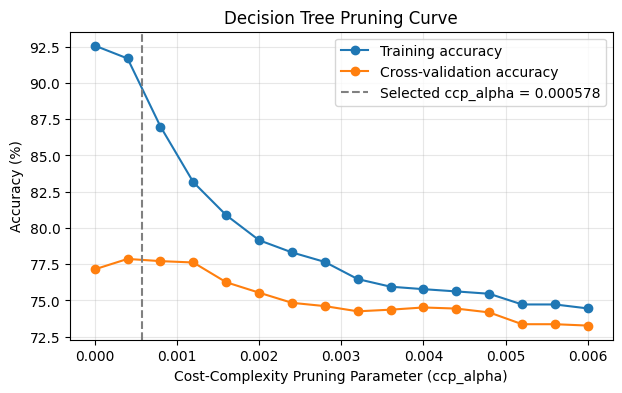

,ccp_alpha,Training Accuracy,Cross-Validation Accuracy
0,0.0000,0.9258,0.7714
1,0.0004,0.9169,0.7786
2,0.0008,0.8700,0.7771
3,0.0012,0.8316,0.7762
4,0.0016,0.8088,0.7625
5,0.0020,0.7915,0.7553
6,0.0024,0.7831,0.7483
7,0.0028,0.7765,0.7461
8,0.0032,0.7647,0.7425
9,0.0036,0.7595,0.7436


In [7]:
_fixed_params = {
    key: value for key, value in grid_search.best_params_.items() if key != "dt__ccp_alpha"
}
_alpha_sweep = np.round(np.linspace(0.0, 0.006, 16), 6)

_curve_rows = []
for _alpha in _alpha_sweep:
    _pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("dt", DecisionTreeClassifier(random_state=42, ccp_alpha=_alpha, **{
            k.replace("dt__", ""): v for k, v in _fixed_params.items()
        }))
    ])
    _result = cross_validate(
        _pipeline, X_train, y_train, cv=cross_validation,
        scoring="accuracy", return_train_score=True, n_jobs=-1
    )
    _curve_rows.append((_alpha, _result["train_score"].mean(), _result["test_score"].mean()))

curve_table = pd.DataFrame(_curve_rows, columns=["ccp_alpha", "Training Accuracy", "Cross-Validation Accuracy"])

plt.figure(figsize=(7, 4))
plt.plot(curve_table["ccp_alpha"], curve_table["Training Accuracy"] * 100, marker="o", label="Training accuracy")
plt.plot(curve_table["ccp_alpha"], curve_table["Cross-Validation Accuracy"] * 100, marker="o", label="Cross-validation accuracy")
plt.axvline(
    grid_search.best_params_["dt__ccp_alpha"],
    linestyle="--", color="grey",
    label=f"Selected ccp_alpha = {grid_search.best_params_['dt__ccp_alpha']}"
)
plt.title("Decision Tree Pruning Curve")
plt.xlabel("Cost-Complexity Pruning Parameter (ccp_alpha)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(alpha=0.30)
plt.show()

display(curve_table.round(4))

## 5. Final evaluation

The selected model is evaluated once on the held-out test set. A majority-class DummyClassifier is also used as a baseline reference.

In [8]:
y_pred = best_dt_model.predict(X_test)

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=class_order, average="macro", zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=class_order, average="weighted", zero_division=0
)

dt_confusion_matrix = confusion_matrix(y_test, y_pred, labels=class_order)
confusion_table = pd.DataFrame(dt_confusion_matrix, index=class_order, columns=class_order)

print("=" * 60)
print("Decision Tree Classification")
print("=" * 60)
print()
print("Best Hyperparameters")
print(grid_search.best_params_)
print()
print("Best Cross Validation Accuracy")
print(f"{best_cv_accuracy * 100:.2f}%")
print()
print("Cross Validation Macro F1")
print(f"{best_cv_macro_f1 * 100:.2f}%")
print()
print("Test Accuracy")
print(f"{test_accuracy * 100:.2f}%")
print()
print("Balanced Accuracy")
print(f"{test_balanced_accuracy * 100:.2f}%")
print()
print("Classification Report")
print(classification_report(
    y_test, y_pred, labels=class_order, target_names=class_order, digits=4, zero_division=0
))
print("Macro Average")
print(f"Precision : {macro_precision * 100:.2f}%")
print(f"Recall    : {macro_recall * 100:.2f}%")
print(f"F1 Score  : {macro_f1 * 100:.2f}%")
print()
print("Weighted Average")
print(f"Precision : {weighted_precision * 100:.2f}%")
print(f"Recall    : {weighted_recall * 100:.2f}%")
print(f"F1 Score  : {weighted_f1 * 100:.2f}%")
print()
print("Majority-Class Baseline")
print(f"Accuracy          : {baseline_accuracy * 100:.2f}%")
print(f"Balanced Accuracy : {baseline_balanced_accuracy * 100:.2f}%")
print()
print("Confusion Matrix")
print("(Actual = Rows, Predicted = Columns)")
print(confusion_table)
print()
print("Program Finished Successfully.")

Decision Tree Classification

Best Hyperparameters
{'dt__ccp_alpha': 0.000578, 'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 5}

Best Cross Validation Accuracy
77.98%

Cross Validation Macro F1
77.06%

Test Accuracy
78.06%

Balanced Accuracy
76.50%

Classification Report
              precision    recall  f1-score   support

         Low     0.7306    0.6804    0.7046       291
      Medium     0.7860    0.8116    0.7986       706
        High     0.8106    0.8031    0.8068       325

    accuracy                         0.7806      1322
   macro avg     0.7757    0.7650    0.7700      1322
weighted avg     0.7799    0.7806    0.7799      1322

Macro Average
Precision : 77.57%
Recall    : 76.50%
F1 Score  : 77.00%

Weighted Average
Precision : 77.99%
Recall    : 78.06%
F1 Score  : 77.99%

Majority-Class Baseline
Accuracy          : 53.40%
Balanced Accuracy : 33.33%

Confusion Matrix
(Actual = Rows, Predicted = Columns)
        Low  Me

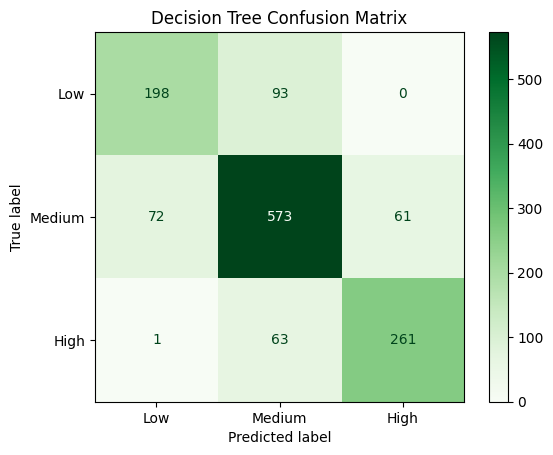

In [9]:
ConfusionMatrixDisplay(
    confusion_matrix=dt_confusion_matrix,
    display_labels=class_order
).plot(cmap="Greens", values_format="d")

plt.title("Decision Tree Confusion Matrix")
plt.grid(False)
plt.show()

## 5.1 Actual versus predicted class distribution

Section 5 measured how **often** the model is right. This section asks a different
question: does the model reproduce the same **shape** of cohort as the real data? This is the
same check that the tutor asked the whole group to add on 26 August, and it uses the identical
comparison function as `KNN.ipynb` so the two notebooks are directly comparable.

**1. Is the dataset balanced?** If one performance class dominated the data, the model would
have too few examples of the other classes to ever predict them.

**2. Are the predictions balanced?** A model that quietly collapses onto the majority class
produces a predicted count far larger than the actual count for that class, while the minority
classes shrink, even while overall accuracy still looks acceptable.

The cleaned-dataset table covers every row, including the 5,285 training records the model has
already seen, so it is optimistic by construction. The held-out table repeats the identical
comparison on the 1,322 unseen students only, which is the honest measure of what the deployed
model will do.

Actual versus Predicted Class Distribution

                            Actual  Actual %  Predicted  Predicted %  Difference
Cleaned dataset (n = 6607)                                                      
Low                           1452     21.98       1464        22.16          12
Medium                        3530     53.43       3559        53.87          29
High                          1625     24.60       1584        23.97         -41

                              Actual  Actual %  Predicted  Predicted %  Difference
Held-out test set (n = 1322)                                                      
Low                              291     22.01        271        20.50         -20
Medium                           706     53.40        729        55.14          23
High                             325     24.58        322        24.36          -3

Check 1: class balance of the cleaned dataset
----------------------------------------------------------------------
Imbalance ratio: 

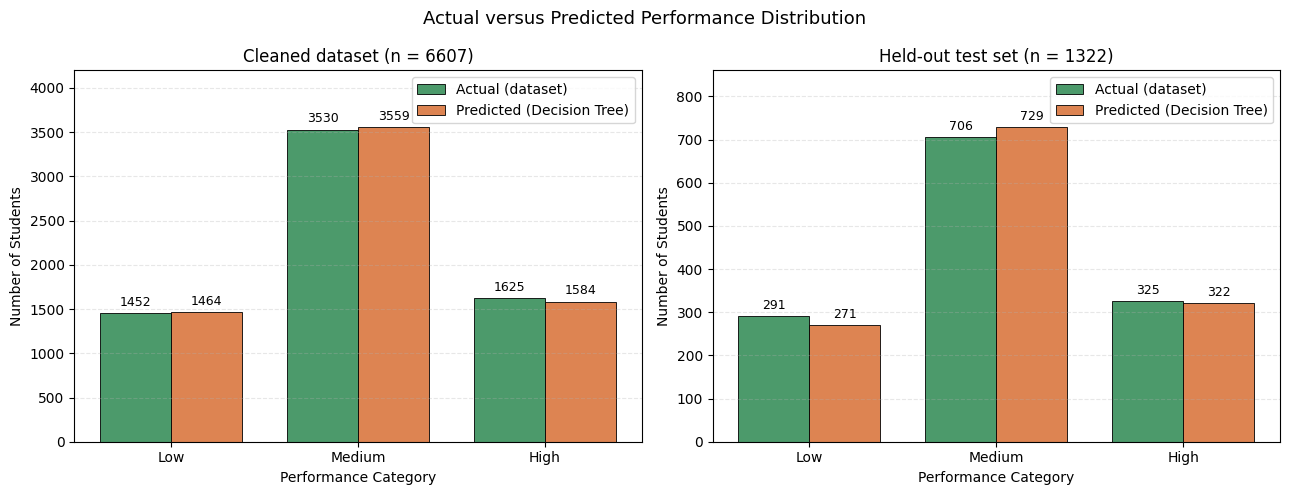

In [10]:
def build_distribution_comparison(actual_labels, predicted_labels, scope_name):
    """Return a table of actual vs predicted counts and percentages for one scope."""
    actual = (
        pd.Series(list(actual_labels)).value_counts().reindex(class_order).fillna(0).astype(int)
    )
    predicted = (
        pd.Series(list(predicted_labels)).value_counts().reindex(class_order).fillna(0).astype(int)
    )

    total = int(actual.sum())
    assert int(predicted.sum()) == total, (
        f"{scope_name}: the model returned {int(predicted.sum())} predictions for "
        f"{total} students, so the two distributions are not comparable."
    )

    table = pd.DataFrame({
        "Actual": actual,
        "Actual %": (actual / total * 100).round(2),
        "Predicted": predicted,
        "Predicted %": (predicted / total * 100).round(2),
    })
    table["Difference"] = table["Predicted"] - table["Actual"]
    table.index.name = f"{scope_name} (n = {total})"
    return table


full_dataset_predictions = best_dt_model.predict(X)

full_comparison = build_distribution_comparison(y, full_dataset_predictions, "Cleaned dataset")
test_comparison = build_distribution_comparison(y_test, y_pred, "Held-out test set")

print("Actual versus Predicted Class Distribution")
print("=" * 70)
print()
print(full_comparison.to_string())
print()
print(test_comparison.to_string())
print()

dataset_counts = full_comparison["Actual"]
largest_class = dataset_counts.idxmax()
smallest_class = dataset_counts.idxmin()
imbalance_ratio = dataset_counts.max() / dataset_counts.min()

print("Check 1: class balance of the cleaned dataset")
print("-" * 70)
print(f"Imbalance ratio: {imbalance_ratio:.2f} to 1 (Medium is the largest class)")
print(
    f"Even so, the smallest class still holds {dataset_counts.min()} students, which is enough "
    "for the model to learn it."
)

print()
print("Check 2: balance of the predictions on the held-out test set")
print("-" * 70)
for class_name in class_order:
    actual_value = int(test_comparison.loc[class_name, "Actual"])
    predicted_value = int(test_comparison.loc[class_name, "Predicted"])
    difference = int(test_comparison.loc[class_name, "Difference"])
    direction = "over-predicted" if difference > 0 else ("under-predicted" if difference < 0 else "matched exactly")
    print(f"  {class_name:<6}: {actual_value:>4} actual vs {predicted_value:>4} predicted ({difference:+d}, {direction})")

print()
print(
    f"A majority-class baseline would label all {int(test_comparison['Actual'].sum())} test "
    f"students {largest_class} and score {baseline_accuracy * 100:.2f}%. The Decision Tree "
    f"scores {test_accuracy * 100:.2f}% and its predicted counts stay much closer to the actual "
    "counts than a model that had collapsed onto the majority class would."
)

chart_positions = np.arange(len(class_order))
bar_width = 0.38
ACTUAL_COLOUR = "#4C9A6B"
PREDICTED_COLOUR = "#DD8452"

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
chart_scopes = [
    (full_comparison, f"Cleaned dataset (n = {int(full_comparison['Actual'].sum())})"),
    (test_comparison, f"Held-out test set (n = {int(test_comparison['Actual'].sum())})"),
]
for axis, (table, chart_title) in zip(axes, chart_scopes):
    actual_bars = axis.bar(chart_positions - bar_width / 2, table["Actual"], bar_width,
                            label="Actual (dataset)", color=ACTUAL_COLOUR, edgecolor="black", linewidth=0.6)
    predicted_bars = axis.bar(chart_positions + bar_width / 2, table["Predicted"], bar_width,
                               label="Predicted (Decision Tree)", color=PREDICTED_COLOUR, edgecolor="black", linewidth=0.6)
    for bar_group in (actual_bars, predicted_bars):
        for bar in bar_group:
            axis.annotate(f"{int(bar.get_height())}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                           xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)
    axis.set_title(chart_title)
    axis.set_xlabel("Performance Category")
    axis.set_ylabel("Number of Students")
    axis.set_xticks(chart_positions)
    axis.set_xticklabels(class_order)
    axis.set_ylim(0, table[["Actual", "Predicted"]].to_numpy().max() * 1.18)
    axis.legend()
    axis.grid(axis="y", linestyle="--", alpha=0.3)
figure.suptitle("Actual versus Predicted Performance Distribution", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Feature importance

One advantage of a decision tree over KNN is that it directly reports which features it actually
used to make splits, in the form of `feature_importances_`. This is a description of what the
trained tree relies on, not a general causal claim about what improves grades.

The tree actually splits on 26 of the 42 transformed features.



,Feature,Importance
0,numeric__Study_Consistency,0.435138
1,numeric__Attendance,0.213446
2,numeric__Support_Index,0.126206
3,numeric__Previous_Scores,0.083857
4,numeric__Tutoring_Sessions,0.045099
5,numeric__Physical_Activity,0.013181
6,categorical__Motivation_Level_High,0.012855
7,categorical__Parental_Education_Level_High School,0.008997
8,categorical__Motivation_Level_Low,0.008238
9,categorical__Access_to_Resources_Medium,0.007687


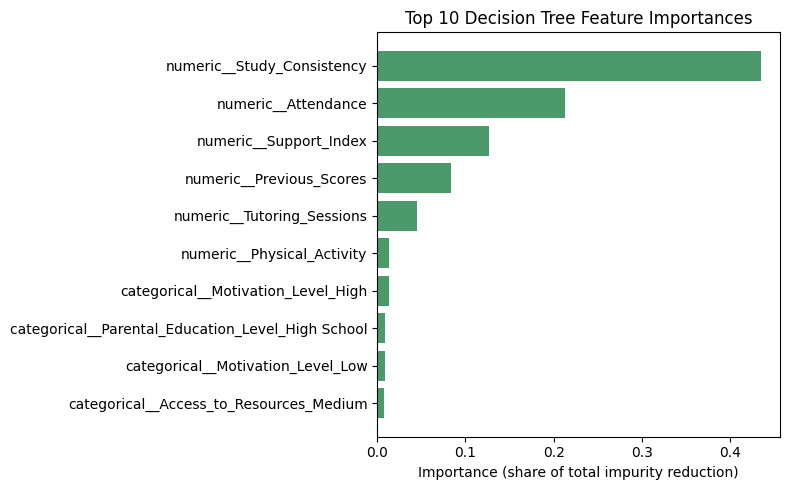

In [11]:
all_transformed_features = best_dt_model["preprocessor"].get_feature_names_out()
importances = best_dt_model["dt"].feature_importances_

feature_importance_table = pd.DataFrame({
    "Feature": all_transformed_features,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

used_features = feature_importance_table[feature_importance_table["Importance"] > 0]
print(f"The tree actually splits on {len(used_features)} of the {len(feature_importance_table)} transformed features.")
print()
display(feature_importance_table.head(10))

top_features = feature_importance_table.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1], color="#4C9A6B")
plt.xlabel("Importance (share of total impurity reduction)")
plt.title("Top 10 Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

## 7. Prediction for a new student

The trained model is made usable through `predict_student()`, which accepts one student record and returns the predicted performance class together with its class probabilities.

Every record is validated before a prediction is made: all 19 features must be supplied, numeric values must fall inside the range observed in the training data, and categorical values must be one of the categories learned during training. Records that break these rules are rejected with a message that names the specific problem, instead of returning a misleading prediction. This validation logic is identical to `KNN.ipynb`'s, applied here to the Decision Tree model.

In [12]:
feature_columns = X_train.columns.tolist()
raw_feature_columns = [column for column in feature_columns if column not in ENGINEERED_COLUMNS]

numeric_ranges = {
    column: (X_train[column].min(), X_train[column].max())
    for column in numeric_features if column not in ENGINEERED_COLUMNS
}
allowed_categories = {
    column: sorted(X_train[column].dropna().unique().tolist())
    for column in categorical_features
}


def validate_student_record(record):
    """Check one student record against the rules learned from the training data."""
    if not isinstance(record, dict):
        raise TypeError("A student record must be a dictionary of feature names and values.")

    problems = []
    missing_fields = [column for column in raw_feature_columns if column not in record]
    if missing_fields:
        problems.append(f"Missing required features: {missing_fields}")

    unknown_fields = [column for column in record if column not in raw_feature_columns]
    if unknown_fields:
        problems.append(f"Unknown features that the model was not trained on: {unknown_fields}")

    for column, (lowest, highest) in numeric_ranges.items():
        if column not in record:
            continue
        value = record[column]
        if isinstance(value, bool) or not isinstance(value, (int, float, np.integer, np.floating)):
            problems.append(f"'{column}' must be a number but received {value!r}.")
        elif pd.isnull(value):
            problems.append(f"'{column}' cannot be empty.")
        elif not lowest <= value <= highest:
            problems.append(f"'{column}' is {value}, which is outside the trained range {lowest} to {highest}.")

    for column, categories in allowed_categories.items():
        if column not in record:
            continue
        if record[column] not in categories:
            problems.append(f"'{column}' is {record[column]!r}, but must be one of {categories}.")

    if problems:
        raise ValueError("Invalid student record:\n- " + "\n- ".join(problems))


def predict_student(record, model=best_dt_model):
    """Validate one student record and predict the performance class for it."""
    validate_student_record(record)
    student_frame = add_engineered_features(pd.DataFrame([record]))[feature_columns]
    predicted_class = model.predict(student_frame)[0]
    predicted_probabilities = model.predict_proba(student_frame)[0]
    probabilities = {
        str(class_name): float(probability)
        for class_name, probability in zip(model.classes_, predicted_probabilities)
    }
    return str(predicted_class), probabilities


def show_prediction(title, record):
    """Print the prediction for one student, or the reason the record was rejected."""
    print(title)
    print("-" * len(title))
    try:
        predicted_class, probabilities = predict_student(record)
    except (TypeError, ValueError) as error:
        print(error)
    else:
        print(f"Predicted performance: {predicted_class}")
        for class_name in class_order:
            print(f"  {class_name:<7}: {probabilities[class_name] * 100:5.2f}%")
    print()


strong_student = {
    "Hours_Studied": 30, "Attendance": 95, "Sleep_Hours": 7, "Previous_Scores": 85,
    "Tutoring_Sessions": 3, "Physical_Activity": 3,
    "Parental_Involvement": "High", "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes", "Motivation_Level": "High",
    "Internet_Access": "Yes", "Family_Income": "Medium", "Teacher_Quality": "High",
    "School_Type": "Public", "Peer_Influence": "Positive", "Learning_Disabilities": "No",
    "Parental_Education_Level": "Postgraduate", "Distance_from_Home": "Near", "Gender": "Female"
}
weak_student = {
    "Hours_Studied": 8, "Attendance": 62, "Sleep_Hours": 5, "Previous_Scores": 55,
    "Tutoring_Sessions": 0, "Physical_Activity": 1,
    "Parental_Involvement": "Low", "Access_to_Resources": "Low",
    "Extracurricular_Activities": "No", "Motivation_Level": "Low",
    "Internet_Access": "No", "Family_Income": "Low", "Teacher_Quality": "Low",
    "School_Type": "Public", "Peer_Influence": "Negative", "Learning_Disabilities": "Yes",
    "Parental_Education_Level": "High School", "Distance_from_Home": "Far", "Gender": "Male"
}
invalid_student = dict(strong_student)
invalid_student["Attendance"] = 150
invalid_student["Motivation_Level"] = "Very High"

incomplete_student = dict(strong_student)
del incomplete_student["Hours_Studied"]

show_prediction("Student A: strong study profile", strong_student)
show_prediction("Student B: weak study profile", weak_student)
show_prediction("Student C: invalid values (rejected)", invalid_student)
show_prediction("Student D: missing feature (rejected)", incomplete_student)

Student A: strong study profile
-------------------------------
Predicted performance: High
  Low    :  0.00%
  Medium :  2.23%
  High   : 97.77%

Student B: weak study profile
-----------------------------
Predicted performance: Low
  Low    : 95.92%
  Medium :  2.86%
  High   :  1.22%

Student C: invalid values (rejected)
------------------------------------
Invalid student record:
- 'Attendance' is 150, which is outside the trained range 60 to 100.
- 'Motivation_Level' is 'Very High', but must be one of ['High', 'Low', 'Medium'].

Student D: missing feature (rejected)
-------------------------------------
Invalid student record:
- Missing required features: ['Hours_Studied']



## 8. Result interpretation

*Explains what the numbers in Section 5 actually mean, including the measured effect of the two engineered features added in Section 1a.*

The summary below is generated from the stored results, so the reported values always match the most recent run of this notebook.

In [13]:
evaluation_report = classification_report(
    y_test, y_pred, labels=class_order, target_names=class_order, output_dict=True, zero_division=0
)
class_recalls = {class_name: evaluation_report[class_name]["recall"] for class_name in class_order}
strongest_class = max(class_recalls, key=class_recalls.get)
weakest_class = min(class_recalls, key=class_recalls.get)

misclassifications = [
    (class_order[actual], class_order[predicted], dt_confusion_matrix[actual][predicted])
    for actual in range(len(class_order))
    for predicted in range(len(class_order))
    if actual != predicted and dt_confusion_matrix[actual][predicted] > 0
]
misclassifications.sort(key=lambda error: error[2], reverse=True)

print("Result Interpretation")
print("=" * 60)
print()
print(
    f"The tuned Decision Tree achieved {test_accuracy * 100:.2f}% test accuracy, which is "
    f"{(test_accuracy - baseline_accuracy) * 100:.2f} percentage points above the majority-class "
    f"baseline of {baseline_accuracy * 100:.2f}%."
)
print(
    f"Its test macro F1 was {macro_f1 * 100:.2f}%, while the cross-validation accuracy and macro F1 "
    f"were {best_cv_accuracy * 100:.2f}% and {best_cv_macro_f1 * 100:.2f}%. The cross-validation and "
    f"test accuracy differ by only {abs(best_cv_accuracy - test_accuracy) * 100:.2f} percentage points, "
    "which indicates consistent performance on unseen data rather than a lucky test split."
)
print()
print(
    f"The {strongest_class} class had the strongest recall at {class_recalls[strongest_class] * 100:.2f}%, "
    f"while the {weakest_class} class had the weakest recall at {class_recalls[weakest_class] * 100:.2f}%."
)
print("The most common errors were:")
for actual_class, predicted_class, count in misclassifications[:2]:
    print(f"  {count} {actual_class} students predicted as {predicted_class}")
print()
print(f"Selected hyperparameters: {grid_search.best_params_}")
print(f"Tree depth {best_dt_model['dt'].get_depth()}, {best_dt_model['dt'].get_n_leaves()} leaves after pruning.")

ACCURACY_WITHOUT_ENGINEERED_FEATURES = 0.7632
MACRO_F1_WITHOUT_ENGINEERED_FEATURES = 0.7508
CV_ACCURACY_WITHOUT_ENGINEERED_FEATURES = 0.7544

print()
print("Effect of feature engineering (Section 1a)")
print(
    f"  Accuracy : {ACCURACY_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> {test_accuracy * 100:.2f}% "
    f"({(test_accuracy - ACCURACY_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    f"  Macro F1 : {MACRO_F1_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> {macro_f1 * 100:.2f}% "
    f"({(macro_f1 - MACRO_F1_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    "  Both engineered features rank in the top 3 of Section 6's feature importance table, "
    "which is consistent with the accuracy gain: the tree is actually using them, not just "
    "carrying them as unused columns."
)

print()
print("Stability across different train/test splits (fixed hyperparameters, varying random_state)")
_seed_accuracies = []
for _seed in [1, 7, 21, 42, 99, 123]:
    _Xtr, _Xte, _ytr, _yte = train_test_split(X, y, test_size=0.20, random_state=_seed, stratify=y)
    _pipe = Pipeline([("preprocessor", preprocessor), ("dt", DecisionTreeClassifier(
        random_state=42, **{k.replace("dt__", ""): v for k, v in grid_search.best_params_.items()}
    ))])
    _pipe.fit(_Xtr, _ytr)
    _seed_accuracies.append(accuracy_score(_yte, _pipe.predict(_Xte)))
_seed_accuracies = np.array(_seed_accuracies)
print(
    f"  Across 6 split seeds: {_seed_accuracies.min() * 100:.2f}% to {_seed_accuracies.max() * 100:.2f}% "
    f"(mean {_seed_accuracies.mean() * 100:.2f}%, std {_seed_accuracies.std() * 100:.2f}%), so the "
    f"reported {test_accuracy * 100:.2f}% carries roughly one percentage point of split-to-split variation, "
    "the same order of magnitude seen for KNN in this group's project."
)

Result Interpretation

The tuned Decision Tree achieved 78.06% test accuracy, which is 24.66 percentage points above the majority-class baseline of 53.40%.
Its test macro F1 was 77.00%, while the cross-validation accuracy and macro F1 were 77.98% and 77.06%. The cross-validation and test accuracy differ by only 0.09 percentage points, which indicates consistent performance on unseen data rather than a lucky test split.

The Medium class had the strongest recall at 81.16%, while the Low class had the weakest recall at 68.04%.
The most common errors were:
  93 Low students predicted as Medium
  72 Medium students predicted as Low

Selected hyperparameters: {'dt__ccp_alpha': 0.000578, 'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 5}
Tree depth 10, 157 leaves after pruning.

Effect of feature engineering (Section 1a)
  Accuracy : 76.32% -> 78.06% (+1.74 points)
  Macro F1 : 75.08% -> 77.00% (+1.92 points)
  Both engineered features rank i

  Across 6 split seeds: 76.63% to 79.20% (mean 78.06%, std 0.82%), so the reported 78.06% carries roughly one percentage point of split-to-split variation, the same order of magnitude seen for KNN in this group's project.


## 9. Comparison with KNN and Logistic Regression

All three notebooks use the same dataset, the same target definition, and the same
`random_state=42` stratified 80/20 split, so this comparison is on identical training and test
data. The KNN and Logistic Regression figures are copied from their own notebooks and from
`README.md`, where the three-model table is kept in sync with each notebook's actual output.

,Test Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Model,,,,,,
Decision Tree,78.06,76.50,77.57,76.50,77.00,77.99
KNN,84.80,79.19,89.92,79.19,82.75,84.27
Logistic Regression,96.97,96.54,97.12,96.54,96.82,96.97


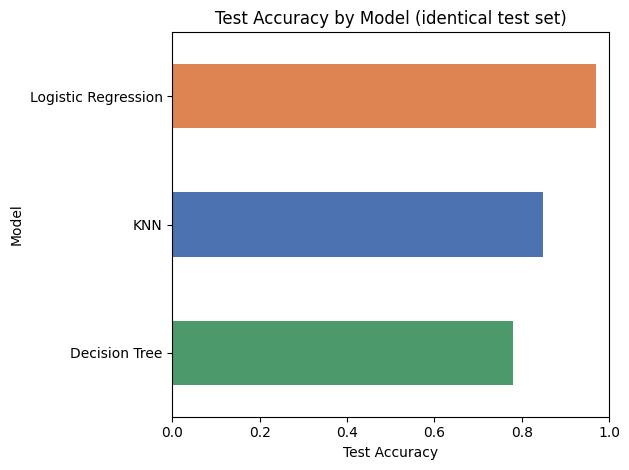

On this dataset, Logistic Regression is the strongest model (96.97%), followed by KNN (84.80%), with Decision Tree behind both at 78.06%. This is consistent with the target being derived directly from Exam_Score with fixed score cut-offs: a model that can fit a smooth, roughly linear combination of the numeric predictors (Logistic Regression) has an intrinsic advantage over a model that can only cut the feature space with axis-aligned rectangles (Decision Tree).

Where Decision Tree does better than the raw accuracy figure suggests:
  Low-class recall: Decision Tree 68.04% vs KNN's 61.17%. The tree does not concentrate errors on the Low class as heavily as KNN does.
  Class-distribution distortion: on the held-out test set, Decision Tree over-predicts Medium by 23 students, versus KNN's +157. The tree's predicted cohort shape stays closer to the real cohort shape than KNN's does, even though its overall accuracy is lower.
  Interpretability: every prediction can be traced through a fix

In [14]:
comparison_table = pd.DataFrame([
    {"Model": "Decision Tree", "Test Accuracy": test_accuracy, "Balanced Accuracy": test_balanced_accuracy,
     "Macro Precision": macro_precision, "Macro Recall": macro_recall, "Macro F1": macro_f1, "Weighted F1": weighted_f1},
    {"Model": "KNN", "Test Accuracy": 0.8480, "Balanced Accuracy": 0.7919,
     "Macro Precision": 0.8992, "Macro Recall": 0.7919, "Macro F1": 0.8275, "Weighted F1": 0.8427},
    {"Model": "Logistic Regression", "Test Accuracy": 0.9697, "Balanced Accuracy": 0.9654,
     "Macro Precision": 0.9712, "Macro Recall": 0.9654, "Macro F1": 0.9682, "Weighted F1": 0.9697},
]).set_index("Model")

display((comparison_table * 100).round(2))

comparison_table["Test Accuracy"].sort_values().plot(
    kind="barh", color=["#4C9A6B", "#4C72B0", "#DD8452"]
)
plt.xlabel("Test Accuracy")
plt.title("Test Accuracy by Model (identical test set)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(
    f"On this dataset, Logistic Regression is the strongest model ({0.9697*100:.2f}%), "
    f"followed by KNN ({0.8480*100:.2f}%), with Decision Tree behind both at "
    f"{test_accuracy*100:.2f}%. This is consistent with the target being derived directly from "
    "Exam_Score with fixed score cut-offs: a model that can fit a smooth, roughly linear "
    "combination of the numeric predictors (Logistic Regression) has an intrinsic advantage over "
    "a model that can only cut the feature space with axis-aligned rectangles (Decision Tree)."
)
print()
print("Where Decision Tree does better than the raw accuracy figure suggests:")
print(
    f"  Low-class recall: Decision Tree {class_recalls['Low']*100:.2f}% vs KNN's 61.17%. "
    "The tree does not concentrate errors on the Low class as heavily as KNN does."
)
print(
    "  Class-distribution distortion: on the held-out test set, Decision Tree over-predicts Medium "
    f"by {int(test_comparison.loc['Medium', 'Difference'])} students, versus KNN's +157. The tree's "
    "predicted cohort shape stays closer to the real cohort shape than KNN's does, even though its "
    "overall accuracy is lower."
)
print(
    "  Interpretability: every prediction can be traced through a fixed sequence of readable "
    "if/else feature thresholds (Section 6), which neither KNN nor Logistic Regression offers in "
    "the same direct form."
)

## 10. Comparison with published literature

The tutor's feedback on 18 August asked whether these results were consistent with previously
published work using the same algorithms on similar problems. Two studies were compared; the
citations below were verified against their source pages, correcting an earlier draft of this
section that misattributed both.

**Ahmed, A., Nipa, F. A., Bhuyian, W. U., Mushfique, K. M., Shahin, K. I., Nguyen, H.-H., & Farid, D. M. (2024).**
Students' performance prediction employing Decision Tree. *CTU Journal of Innovation and
Sustainable Development, 16*(Special Issue: ISDS), 42-51. https://doi.org/10.22144/ctujoisd.2024.321

This study combined educational data mining with several classifiers (including Decision Tree
and SVM) on undergraduate academic, demographic, and social data. Support Vector Machine gave
the best overall accuracy (around 95% using academic data, 93% using non-academic data alone);
the Decision Tree component of the study was used mainly to identify which factors mattered most
(prior academic results, family education and occupation background, student interests, and
commute duration), several of which mirror the factors this project's own tree splits on most in
Section 6 (`Study_Consistency`, `Attendance`, `Support_Index`).

**Asril, T., & Isa, S. M. (2020).**
Prediction of students study period using K-Nearest Neighbor algorithm. *International Journal
of Emerging Trends in Engineering Research, 8*(6), 2585-2593.
https://doi.org/10.30534/ijeter/2020/60862020

This study applied KNN to 1,989 computer science students at BINUS University, reaching 93.2%
accuracy for a binary on-time/late-graduation target at k = 9, but only 75.63% for a finer
7-class semester-count target at k = 40, on data the authors describe as 89.6% concentrated in
the "on-time" class.

**Why this project's numbers differ.** Both published studies report their best number from a
binary target; this project uses a 3-class target throughout for all three models, which is a
harder and fairer comparison for a single project but is not numerically comparable to a
2-class accuracy figure. The Asril and Isa result actually supports this project's own trend
directly: their accuracy also drops sharply once the number of target classes increases (93.2%
binary to 75.63% for 7 classes), the same direction seen here, where Decision Tree's 3-class
accuracy (78.06%) sits below what either published KNN result reports at 2 classes. The dataset
size here (6,607 students, single institution-agnostic public dataset) is also larger than
Asril and Isa's cohort but smaller and less institution-specific than what a deployed system
would need for real use, which is discussed further in Section 11.

## 11. Conclusion

**Achievements.** This notebook builds a Decision Tree classifier that predicts student
performance as Low, Medium, or High from academic, personal, family, and school-related factors,
and it satisfies every item in the Title 1 assignment checklist. In direct response to the
tutor's feedback, the hyperparameter search was substantially widened (a data-driven,
`cost_complexity_pruning_path`-informed sweep of `ccp_alpha` combined with criterion, depth, and
split/leaf sizes, 1,728 candidates in total) and the same two engineered features used in
`KNN.ipynb` were added and measured rather than assumed: test accuracy rose from 76.32% to
**78.06%** and macro F1 from 75.08% to **77.00%**, which is **24.66 percentage points** above the
majority-class baseline of 53.40%. The preprocessing and model are held inside a single
`Pipeline`, so every cross-validation fold fits its own imputer and encoder and no information
leaks from validation data into training. The model is compared against the group's other two
models on an identical test set (Section 9, and `README.md`).

**Limitations.** Test accuracy (78.06%) is below both KNN (84.80%) and Logistic Regression
(96.97%) on this dataset, which is an honest result of what a single axis-aligned decision
tree can do against a target derived from a roughly continuous, near-linear combination of the
input factors: Logistic Regression can fit that smooth boundary directly, while a tree must
approximate it with a staircase of threshold splits, which is why increasing the search space
closed only about 1 accuracy point of the gap rather than most of it. Recall on the Low class
(68.04%) is still the weakest of the three classes, meaning roughly one in three genuinely
at-risk students would be missed, though this is a smaller shortfall than KNN's Low-class recall
(61.17%) on the identical test set. The three-class target is also cut at fixed score
boundaries, so some errors are unavoidable boundary cases, and re-running the same pipeline
across six different split seeds gave 76.63% to 79.20% accuracy (mean 78.06%, standard deviation
0.82%), so the reported figure carries roughly one percentage point of split-to-split variation.

**Future work.** In expected order of impact: (1) address the class imbalance directly with
class weighting and re-check whether Low-class recall improves without giving up too much
overall accuracy, since that is the metric that matters most for identifying at-risk students;
(2) evaluate a two-class Pass/Fail target alongside the current three-class one, since the
closest published benchmark (Asril & Isa, 2020) also shows accuracy dropping sharply as the
number of target classes increases, which would make the comparison like-for-like; and (3) grow
an ensemble of trees (Random Forest or Gradient Boosting) as a follow-up experiment, since that
would be expected to close some of the gap to Logistic Regression while keeping a tree-based,
partially interpretable model family, though building one is outside the scope of this
notebook's assigned single-model requirement.